In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid")

In [2]:
chicks = pd.read_csv("chickwts(2).csv")
feed_means = chicks.groupby("feed")["weight"].mean().sort_values()
feed_means

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

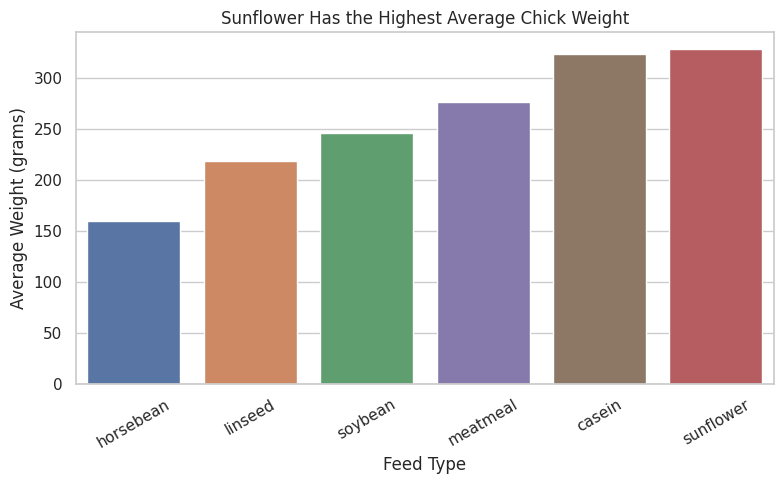

In [3]:
order = feed_means.index
plt.figure(figsize=(8, 5))
sns.barplot(data=chicks, x="feed", y="weight", hue="feed", order=order, errorbar=None, legend=False)
plt.title("Sunflower Has the Highest Average Chick Weight")
plt.xlabel("Feed Type")
plt.ylabel("Average Weight (grams)")
plt.xticks(rotation=30)
plt.ylim(0, None)
plt.tight_layout()
plt.show()

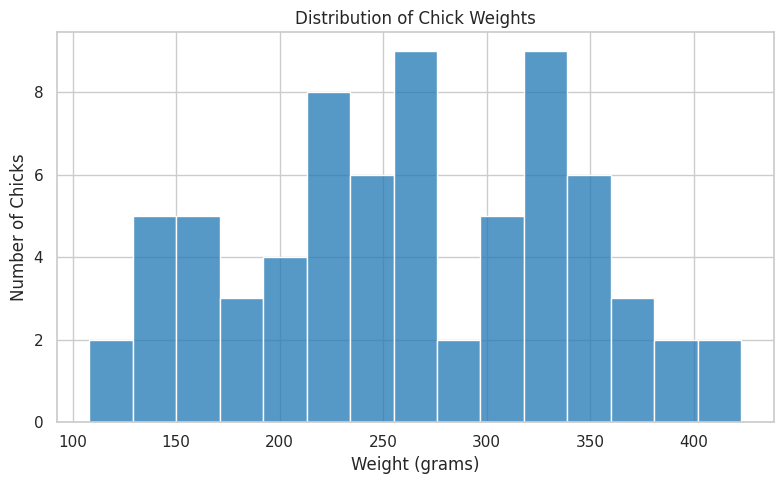

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=chicks, x="weight", bins=15, color="tab:blue")
plt.title("Distribution of Chick Weights")
plt.xlabel("Weight (grams)")
plt.ylabel("Number of Chicks")
plt.tight_layout()
plt.show()

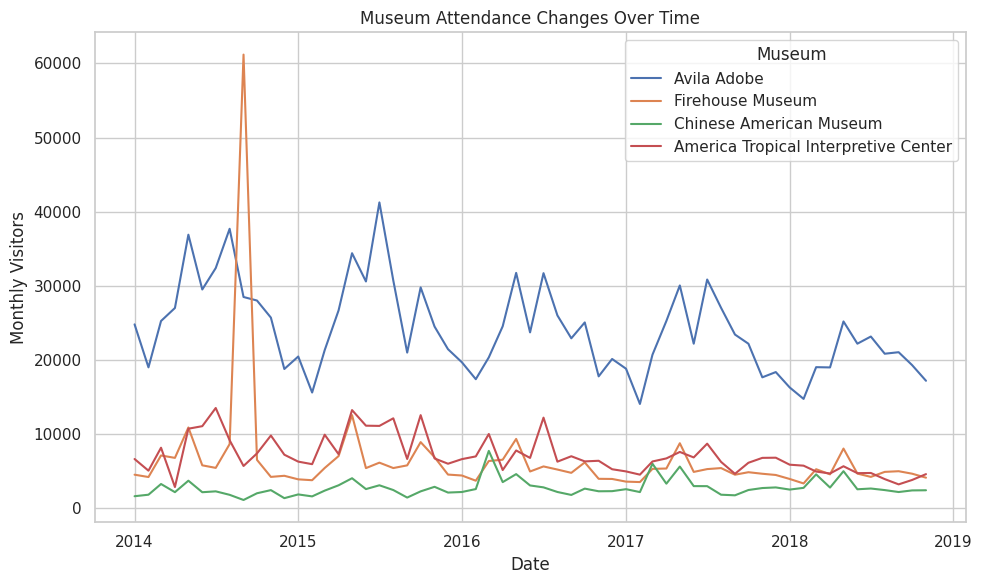

In [5]:
museum = pd.read_csv("museum_visitors.csv")
museum["Date"] = pd.to_datetime(museum["Date"])

museum_long = museum.melt(id_vars="Date", var_name="Museum", value_name="Visitors")
plt.figure(figsize=(10, 6))
sns.lineplot(data=museum_long, x="Date", y="Visitors", hue="Museum")
plt.title("Museum Attendance Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly Visitors")
plt.tight_layout()
plt.show()

**Museum trend:** The number of museum visitors changes over time, with some months having more visitors than others.

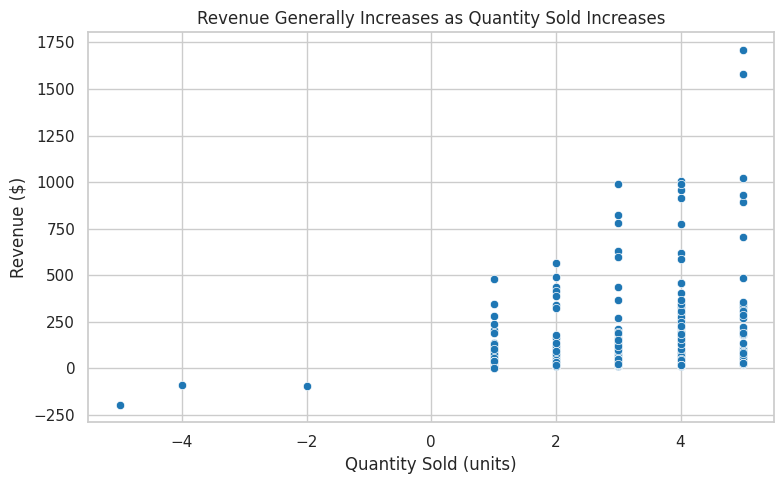

In [6]:
sales = pd.read_csv("sales_clean(2).csv")
sales["revenue"] = sales["price"] * sales["qty"]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sales, x="qty", y="revenue", color="tab:blue")
plt.title("Revenue Generally Increases as Quantity Sold Increases")
plt.xlabel("Quantity Sold (units)")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

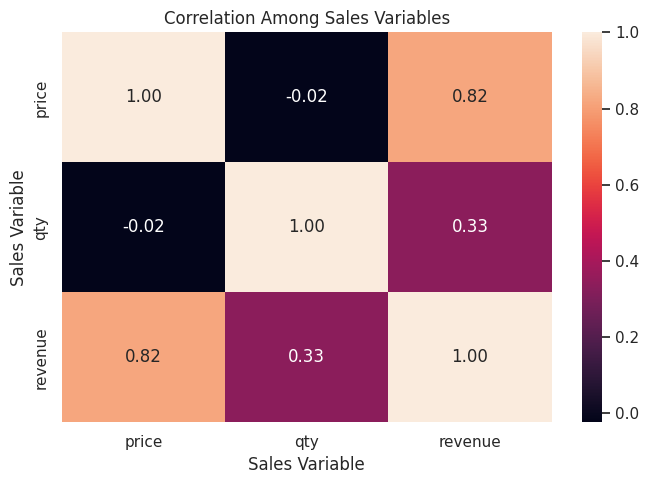

,price,qty,revenue
price,1.000000,-0.023683,0.817699
qty,-0.023683,1.000000,0.334196
revenue,0.817699,0.334196,1.000000


In [7]:
corr = sales[["price", "qty", "revenue"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Among Sales Variables")
plt.xlabel("Sales Variable")
plt.ylabel("Sales Variable")
plt.tight_layout()
plt.show()

corr

**Strongest off-diagonal correlation:** Price and revenue have the strongest correlation at about **0.82**.

**Null hypothesis:** There isn't a difference between the average weight of chicks fed casein and chicks fed horsebean.

In [8]:
casein = chicks[chicks["feed"] == "casein"]["weight"]
horsebean = chicks[chicks["feed"] == "horsebean"]["weight"]

t_stat, p_value = ttest_ind(casein, horsebean)
difference = casein.mean() - horsebean.mean()

print(f"Casein mean: {casein.mean():.2f} g")
print(f"Horsebean mean: {horsebean.mean():.2f} g")
print(f"Difference: {difference:.2f} g")
print(f"t statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f}")

Casein mean: 323.58 g
Horsebean mean: 160.20 g
Difference: 163.38 g
t statistic: 7.0197
p-value: 0.0000008255


**T-test conclusion:** The casein-fed chicks weighed an average of about 163.38 grams more than the horsebean-fed chicks. The p-value was 0.00000083, which is below 0.05, so the results show a difference between the two groups. The results should be read carefully because the sample sizes are small.

**Honest-chart audit:** For the bar chart, I put grams on the y-axis so it is clear what the values represent. I also used a zero baseline so the differences between the feed groups are not wrong.

### AI Use Appendix

**Tool:** ChatGPT  
**Use:** Help with seaborn chart syntax, correlation code, t-test code, and preparing the notebook/PDF.  
**Key prompt:** Help build the Module 5 lab charts and statistical code using the uploaded chick weights, museum visitors, and sales datasets.